# From a QASM circuit to a tqec stim circuit, through topologiq

This notebook walks one small circuit (Bernstein-Vazirani on 6 qubits,
15 gates) through the whole chain, one step per cell:

QASM -> **topologiq** (3D space-time diagram) -> **our bridge** (two
small fixes) -> **tqec** (stim circuit) -> p=0 checks.

Every step saves its artifact into `data/` or `figures/` with the cell
number as prefix, so you can inspect each intermediate file directly.
The two fixes are explained in the README; the point of this notebook
is to make each transformation visible.


## 1. The input: a 6-qubit Bernstein-Vazirani circuit (unitary part)

In [1]:
import pathlib, sys, contextlib, io
HERE = pathlib.Path.cwd()
for sub in ("data", "figures"):
    (HERE / sub).mkdir(exist_ok=True)
sys.path.insert(0, str(HERE))

QASM = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[6];
x q[5];
h q[0];
h q[1];
h q[2];
h q[3];
h q[4];
h q[5];
cx q[0],q[5];
cx q[2],q[5];
cx q[4],q[5];
h q[0];
h q[1];
h q[2];
h q[3];
h q[4];
"""
(HERE / "data" / "1_bv_6.qasm").write_text(QASM)
print(QASM)
print("15 gates on 6 qubits; hidden string 10101; q5 is the phase ancilla.")

OPENQASM 2.0;
include "qelib1.inc";
qreg q[6];
x q[5];
h q[0];
h q[1];
h q[2];
h q[3];
h q[4];
h q[5];
cx q[0],q[5];
cx q[2],q[5];
cx q[4],q[5];
h q[0];
h q[1];
h q[2];
h q[3];
h q[4];

15 gates on 6 qubits; hidden string 10101; q5 is the phase ancilla.


## 2. topologiq: circuit -> ZX graph -> 3D space-time diagram (.bgraph)


=> Ingesting PyZX graph.
 - WARNING. PyZX Pauli webs unavailable for reduced graph, which can hinder lattice surgery.
BLOCKGRAPH 0.1.0;

METADATA: attr_name; value;
source; topologiq;
circuit_name; 2_bv_6_topologiq;

CUBES: index;x;y;z;kind;label;
0;0;0;0;OOO;in_0;
1;None;None;None;;in_1;
2;1;1;5;OOO;in_2;
3;None;None;None;;in_3;
4;2;1;5;OOO;in_4;
5;0;1;5;OOO;in_5;
6;0;0;5;XZZ;;
7;0;0;1;ZXX;;
8;None;None;None;;;
9;1;0;5;ZXX;;
10;None;None;None;;;
11;2;0;5;ZXX;;
12;0;0;4;ZXX;;
13;0;0;3;ZXZ;;
14;0;0;2;ZXX;;
15;1;0;3;ZXZ;;
16;1;0;4;ZXX;;
17;2;0;3;ZXZ;;
18;2;0;4;ZXX;;
19;0;1;2;XXZ;;
20;None;None;None;;;
21;1;1;4;XXZ;;
22;None;None;None;;;
23;2;1;4;XXZ;;
24;1;1;2;OOO;out_0;
25;None;None;None;;out_1;
26;1;2;4;OOO;out_2;
27;None;None;None;;out_3;
28;3;1;4;OOO;out_4;
29;3;0;3;OOO;out_5;

PIPES: src;tgt;kind;
0;7;XZOH;
1;8;None;
2;9;ZOXH;
3;10;None;
4;11;ZOXH;
5;6;XOZ;
6;12;ZXOH;
7;14;ZXO;
8;20;None;
9;16;ZXO;
10;22;None;
11;18;ZXO;
12;13;ZXO;
13;14;ZXO;
13;15;OXZ;
14;19;ZOXH;
15;16;ZXO;
15;17

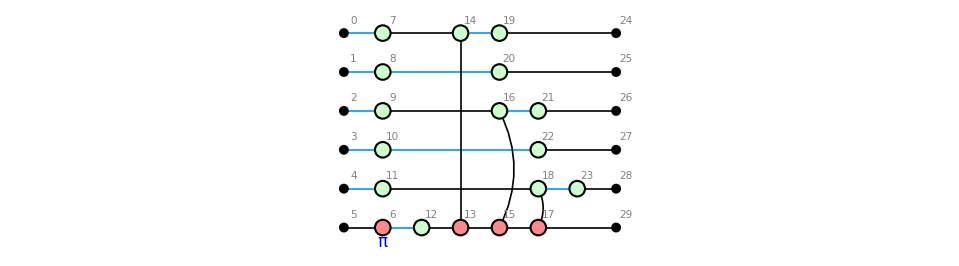

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from topologiq.core.graph_manager import graph_manager as gm
gm.BGRAPH_DIR = HERE / "data"
from topologiq.input.zx_manager import ZXGraphManager

zxm = ZXGraphManager()
aug = zxm.add_graph_from_qasm(path_to_qasm_file=HERE / "data" / "1_bv_6.qasm",
                              graph_key="bv_6")
import pyzx as zx
fig = zx.draw_matplotlib(aug.zx_graph, labels=True)
fig.savefig(HERE / "figures" / "2_bv_6_zx_graph.png", dpi=150,
            bbox_inches="tight")
plt.close(fig)
with contextlib.redirect_stdout(io.StringIO()):
    mgr = gm.BlockGraphManager(aug, debug=0, seed=0)
    mgr.build()
    mgr.write_bgraph("2_bv_6_topologiq")
raw = (HERE / "data" / "2_bv_6_topologiq.bgraph").read_text()
print(raw)
print("Note the None entries: qubits q1 and q3 never interact (their "
      "secret bits are 0), their wires form separate graph components, "
      "and topologiq's default traversal leaves them without positions.")
from IPython.display import Image, display
display(Image(str(HERE / "figures" / "2_bv_6_zx_graph.png"), width=640))

## 3. The bridge, fix 1: drop the positionless entries

In [3]:
clean = "\n".join(l for l in raw.splitlines() if "None" not in l)
(HERE / "data" / "3_bv_6_clean.bgraph").write_text(clean)
dropped = [l for l in raw.splitlines() if "None" in l]
print(f"dropped {len(dropped)} lines:")
print("\n".join(dropped))
from tqec import BlockGraph
g_before = BlockGraph.from_bgraph(clean)
g_before.validate()
print(f"\ntqec reads the cleaned file: {g_before.num_cubes} cubes, "
      f"{g_before.num_pipes} pipes, {g_before.num_ports} ports -- validate OK")
html = g_before.view_as_html(write_html_filepath=str(
    HERE / "figures" / "3_bv_6_before_rewrite.html"))
from IPython.display import IFrame, display
print("the 3D diagram as topologiq made it (drag to rotate); the H pipes "
      "(color-flip rings) sit directly on the junction cubes:")
display(IFrame("figures/3_bv_6_before_rewrite.html", width=760, height=440))

dropped 14 lines:
1;None;None;None;;in_1;
3;None;None;None;;in_3;
8;None;None;None;;;
10;None;None;None;;;
20;None;None;None;;;
22;None;None;None;;;
25;None;None;None;;out_1;
27;None;None;None;;out_3;
1;8;None;
3;10;None;
8;20;None;
10;22;None;
20;25;None;
22;27;None;



tqec reads the cleaned file: 22 cubes, 21 pipes, 8 ports -- validate OK


the 3D diagram as topologiq made it (drag to rotate); the H pipes (color-flip rings) sit directly on the junction cubes:


## 4. The bridge, fix 2: slide the Hadamard pipes off the junction cubes

In [4]:
import hadamard_rewrite as hr
cubes, pipes = hr.load(clean)
rounds = 0
while True:
    step = hr.stretch_and_fix(cubes, pipes)
    if step is None:
        break
    cubes, pipes = step
    rounds += 1
g_after = hr.to_blockgraph(cubes, pipes)
g_after.validate()
print(f"{rounds} rewrite round(s): {g_before.num_cubes} -> {g_after.num_cubes} cubes "
      f"({g_after.num_cubes - g_before.num_cubes} cubes inserted by the bridge, "
      f"not by topologiq)")
g_after.view_as_html(write_html_filepath=str(
    HERE / "figures" / "4_bv_6_after_rewrite.html"))
print("same computation, stretched by one row: every H pipe now sits "
      "between two regular cubes, which tqec can compile:")
display(IFrame("figures/4_bv_6_after_rewrite.html", width=760, height=440))

1 rewrite round(s): 22 -> 28 cubes (6 cubes inserted by the bridge, not by topologiq)
same computation, stretched by one row: every H pipe now sits between two regular cubes, which tqec can compile:


## 5. tqec: 3D diagram -> stim circuit

In [5]:
from tqec import compile_block_graph
from tqec.compile.convention import FIXED_BOUNDARY_CONVENTION
fg = g_after.fill_ports_for_minimal_simulation()[0]
fgraph = fg.graph if hasattr(fg, "graph") else fg
circ = compile_block_graph(fgraph, observables="auto",
                           convention=FIXED_BOUNDARY_CONVENTION).generate_stim_circuit(k=1)
(HERE / "data" / "5_bv_6_tqec.stim").write_text(str(circ))
print(f"stim circuit: {circ.num_qubits} qubits, {circ.num_detectors} "
      f"detectors, {circ.num_observables} observables (d=3)")

stim circuit: 337 qubits, 810 detectors, 4 observables (d=3)


## 6. p=0 checks: the compiled circuit is a valid computation

In [6]:
det, obs = circ.compile_detector_sampler(seed=1).sample(1024,
                                                        separate_observables=True)
silent = not det.any()
ndet = sum(1 for k in range(obs.shape[1])
           if bool((obs[:, k] == obs[0, k]).all()))
print(f"1024 shots at p=0: detectors silent = {silent}; "
      f"deterministic observables = {ndet}/{obs.shape[1]}")
assert silent and ndet == obs.shape[1]
print("PASS -- the chain QASM -> topologiq -> bridge -> tqec -> stim is closed.")

1024 shots at p=0: detectors silent = True; deterministic observables = 4/4
PASS -- the chain QASM -> topologiq -> bridge -> tqec -> stim is closed.
